In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("car_prediction_data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [6]:
df.shape

(301, 9)

In [7]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(2)

In [9]:
df = df.drop_duplicates()

In [10]:
df.duplicated().sum()

np.int64(0)

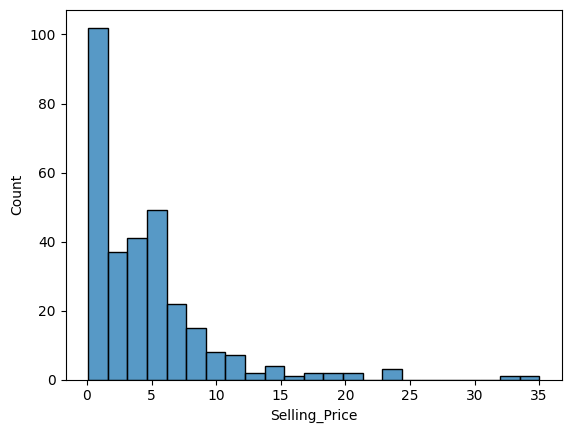

In [11]:
sns.histplot(x='Selling_Price' , data=df)
plt.show()

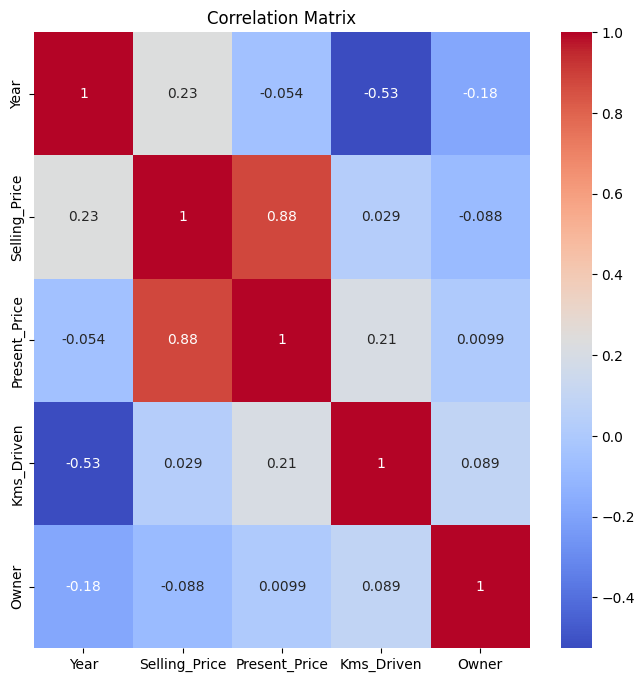

In [12]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = df_numeric.corr()

# Plot heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()
          

In [13]:
df.value_counts('Fuel_Type')


Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

In [14]:
df['Fuel_Type'].unique()

array(['Petrol', 'Diesel', 'CNG'], dtype=object)

In [15]:
df['Seller_Type'].unique()

array(['Dealer', 'Individual'], dtype=object)

In [16]:
df['Transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [17]:
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['Transmission', 'Seller_Type']:
    df[col] = le.fit_transform(df[col])

In [19]:
df = df.drop('Car_Name',axis=1)

In [20]:
df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Seller_Type,Transmission,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol
0,2014,3.35,5.59,27000,0,1,0,False,True
1,2013,4.75,9.54,43000,0,1,0,True,False
2,2017,7.25,9.85,6900,0,1,0,False,True
3,2011,2.85,4.15,5200,0,1,0,False,True
4,2014,4.60,6.87,42450,0,1,0,True,False


In [21]:
df.shape

(299, 9)

In [22]:
import datetime

current_year = datetime.datetime.now().year

df['Car_Age'] = current_year - df['Year'] 

df.drop('Year',axis=1,inplace=True)

df.head()

,Selling_Price,Present_Price,Kms_Driven,Seller_Type,Transmission,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Car_Age
0,3.35,5.59,27000,0,1,0,False,True,12
1,4.75,9.54,43000,0,1,0,True,False,13
2,7.25,9.85,6900,0,1,0,False,True,9
3,2.85,4.15,5200,0,1,0,False,True,15
4,4.60,6.87,42450,0,1,0,True,False,12


In [23]:
x = df.drop('Selling_Price',axis=1)
y = df['Selling_Price']

In [24]:
from sklearn.model_selection import train_test_split 
x_train,x_test, y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [60]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [61]:
y_pred_lr = lr.predict(x_test)
y_pred_lr


array([ 7.50192151,  7.79152142,  1.36644388,  7.00941894, 11.16328988,
        4.53410247,  8.49246345,  1.70078181,  8.82421963, -0.96348801,
       10.31444007, -0.97386896,  0.71832735,  1.53711566,  4.97622203,
        5.04627395,  1.29503012,  1.85159301, 21.56570817,  0.86767992,
        0.93078859,  2.45202839,  5.58169747,  0.2581242 ,  6.26649907,
        7.82350038,  8.68226641,  1.1746619 ,  4.84357381,  4.92069701,
        3.26811058,  5.48959967,  6.27470319,  2.75388094,  2.90385159,
        6.96790194,  1.26406586, -4.97141242,  1.38043678, 10.38468561,
        7.10536052,  9.04017934,  1.62741133,  4.01521109,  0.97463542,
       -2.14675103,  8.1451697 ,  4.37395524,  5.64880685, -0.59577608,
        0.66072164,  0.20325682, 10.20766115,  9.45415687,  7.29949412,
        6.25536738,  3.71408634,  3.43110175,  9.56341995,  9.1600735 ])

In [62]:
lr.score(x_test,y_test)

0.7528154215832916

In [28]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# MAE
mae = mean_absolute_error(y_test, y_pred_lr)

# R2 Score
r2 = r2_score(y_test, y_pred_lr)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("MAE: ")
print(mae)

print("R2_score: ")
print(r2)

print("RMSE: ")
print(rmse)

MAE: 
1.4728924140033002
R2_score: 
0.7528154215832916
RMSE: 
2.5240350545947803


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

In [41]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [42]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(x_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [43]:
y_pred_rf = rf.predict(x_test)
y_pred_rf

array([ 9.6777,  8.1915,  0.438 ,  6.6815, 15.5444,  5.314 ,  6.7797,
        1.18  ,  7.721 ,  0.3416, 13.1409,  0.2048,  0.2332,  0.4509,
        4.3815,  5.3401,  0.5985,  1.1625, 21.7115,  0.5421,  0.5399,
        2.4105,  6.2665,  2.341 ,  6.039 ,  9.2103,  9.0415,  1.1385,
        4.8257,  5.2184,  3.463 ,  4.4595,  5.9875,  2.741 ,  3.248 ,
        6.356 ,  1.154 ,  0.1575,  1.138 , 15.448 ,  7.2604,  9.0563,
        0.9115,  3.5216,  0.5594,  0.202 ,  9.8583,  5.022 ,  4.0215,
        0.2186,  0.6055,  0.3201, 16.1265,  9.986 ,  8.0562,  6.9475,
        3.1525,  3.5855, 10.3514,  7.6504])

In [44]:
rf.score(x_test,y_test)

0.6028579562644075

In [45]:
y_pred_dt = dt.predict(x_test)
y_pred_dt

array([10.11,  8.75,  0.45,  5.95, 14.5 ,  5.5 ,  5.9 ,  1.2 ,  7.9 ,
        0.15,  9.25,  0.25,  0.25,  0.48,  4.  ,  6.1 ,  0.6 ,  1.1 ,
       23.  ,  0.55,  0.55,  2.5 ,  6.6 ,  2.55,  5.65,  8.65, 11.25,
        1.1 ,  4.5 ,  5.95,  4.  ,  4.5 ,  5.65,  2.7 ,  4.  ,  5.95,
        1.15,  0.1 ,  1.1 , 14.5 ,  7.45, 11.25,  1.05,  3.6 ,  0.55,
        0.2 ,  9.15,  5.3 ,  3.5 ,  0.15,  0.65,  0.3 , 16.  , 11.25,
        7.05,  8.25,  2.9 ,  3.45, 11.25,  7.05])

In [46]:
dt.score(x_test,y_test)

0.652022255105377

In [47]:
# MAE
mae = mean_absolute_error(y_test, y_pred_rf)

# R2 Score
r2 = r2_score(y_test, y_pred_rf)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("MAE of Random Forest: ")
print(mae)

print("R2_score of Random Forest: ")
print(r2)

print("RMSE of Random Forest: ")
print(rmse)

MAE of Random Forest: 
1.401970000000001
R2_score of Random Forest: 
0.6028579562644075
RMSE of Random Forest: 
3.1993196202734526


In [48]:
# MAE
mae = mean_absolute_error(y_test, y_pred_dt)

# R2 Score
r2 = r2_score(y_test, y_pred_dt)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("MAE of Decision Tree: ")
print(mae)

print("R2_score of Decision Tree: ")
print(r2)

print("RMSE of Decision Tree: ")
print(rmse)

MAE of Decision Tree: 
1.354833333333333
R2_score of Decision Tree: 
0.652022255105377
RMSE of Decision Tree: 
2.994749015638317


In [49]:
df.dtypes

Selling_Price       float64
Present_Price       float64
Kms_Driven            int64
Seller_Type           int64
Transmission          int64
Owner                 int64
Fuel_Type_Diesel      int64
Fuel_Type_Petrol      int64
Car_Age               int64
dtype: object

In [50]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

In [51]:
df.dtypes

Selling_Price       float64
Present_Price       float64
Kms_Driven            int64
Seller_Type           int64
Transmission          int64
Owner                 int64
Fuel_Type_Diesel      int64
Fuel_Type_Petrol      int64
Car_Age               int64
dtype: object

In [52]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[50,100,200],
    'max_depth':[5,10,15],
    'min_samples_split':[2,5,10]}


In [57]:
grid = GridSearchCV(rf,param_grid,cv=5)
grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the 

In [58]:
print(grid.best_params_)

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}


In [59]:
best_model = grid.best_estimator_
best_model.score(x_test, y_test)

0.5846818519777763